# Phase 1 Step 6 — MLFlow 실험 관리 + Optuna HPO

**목표:** 실험 이력 관리 + 하이퍼파라미터 자동 최적화

| 단계 | 내용 |
|------|------|
| Step A | MLFlow 초기화 & 이전 단계 결과 소급 로깅 |
| Step B | Optuna HPO — WaferCNN 대상, **20 trials** |
| Step C | 최적 파라미터로 최종 모델 재학습 |
| Step D | MLFlow Model Registry 등록 (`champion` alias) |

**HPO 탐색 공간:**
```
lr           : log-uniform [1e-5, 1e-3]
batch_size   : {16, 32, 64}
dropout      : uniform [0.1, 0.5]
weight_decay : log-uniform [1e-5, 1e-2]
```
**MLFlow 실험명:** `wafer-defect-detection`

> **수정 이력:**
> - MLFlow 3.14.0 파일시스템 백엔드 차단 → SQLite 백엔드 (`sqlite:///mlruns/mlflow.db`) 로 전환
> - `train_one_epoch` 이중 forward pass 버그 수정
> - split_indices.pkl 키 이름 다중 형식 대응

## 1. 환경 설정

In [1]:
import os
import json
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A

import mlflow
import mlflow.pytorch
from mlflow import MlflowClient

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로
PROCESSED_DIR  = Path('data/processed')
CHECKPOINT_DIR = Path('checkpoints')
ANALYSIS_DIR   = Path('analysis')
MLRUNS_DIR     = Path('mlruns')
CHECKPOINT_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)
MLRUNS_DIR.mkdir(exist_ok=True)   # SQLite 파일이 저장될 폴더

# ── MLFlow 설정
# MLFlow 3.14.0: 파일시스템 백엔드(mlruns/) maintenance mode 차단
# → SQLite 데이터베이스 백엔드로 전환 (동일 폴더 내 .db 파일)
TRACKING_URI    = 'sqlite:///mlruns/mlflow.db'
EXPERIMENT_NAME = 'wafer-defect-detection'
MODEL_REGISTRY  = 'WaferDefectCNN'

# ── HPO 설정
N_TRIALS         = 20
MAX_EPOCHS_TRIAL = 8
FULL_EPOCHS      = 30
PATIENCE         = 7

# ── 시드
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

CLASS_ORDER = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']
NUM_CLASSES = len(CLASS_ORDER)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'MLFlow  : {mlflow.__version__}')
print(f'Optuna  : {optuna.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'Tracking URI: {TRACKING_URI}')

c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\.venv\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


MLFlow  : 3.14.0
Optuna  : 4.9.0
Device  : cuda
GPU     : NVIDIA GeForce RTX 2060 SUPER
Tracking URI: sqlite:///mlruns/mlflow.db


## 2. 데이터 로드

In [4]:
all_maps_resized = np.load(PROCESSED_DIR / 'all_maps_resized.npy')
print(f'all_maps_resized: {all_maps_resized.shape}  ({all_maps_resized.nbytes/1024**2:.0f} MB)')

with open(PROCESSED_DIR / 'split_indices.pkl', 'rb') as f:
    split = pickle.load(f)

print(f'split_indices.pkl 키: {list(split.keys())}')

# Step 3에서 저장한 키 이름이 다를 수 있으므로 다중 형식 대응
train_idx = split.get('train_idx', split.get('train', None))
val_idx   = split.get('val_idx',   split.get('val',   None))
test_idx  = split.get('test_idx',  split.get('test',  None))

if train_idx is None:
    raise KeyError(f'split_indices.pkl에서 train 인덱스를 찾을 수 없습니다. 키: {list(split.keys())}')

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)
test_idx  = np.array(test_idx)

# 레이블 & 클래스 가중치 로드
encoded_labels = split.get('encoded_labels', split.get('labels', None))
class_weights  = split.get('class_weights',  split.get('weights', None))

# encoded_labels 없으면 직접 구성
if encoded_labels is None:
    import pandas as _pd
    df = _pd.read_pickle('data/raw/LSWMD.pkl')
    def _extract(x):
        if isinstance(x, list): return x[0][0] if (len(x) > 0 and isinstance(x[0], list)) else str(x[0])
        return str(x)
    df['lbl'] = df['failureType'].apply(_extract)
    df_valid = df[df['lbl'].isin(CLASS_ORDER)].reset_index(drop=True)
    encoded_labels = np.array([CLASS_ORDER.index(c) for c in df_valid['lbl'].values])

# class_weights 없으면 계산
if class_weights is None:
    from sklearn.utils.class_weight import compute_class_weight
    train_lbl_tmp = encoded_labels[train_idx].astype(int)
    cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_lbl_tmp)
    class_weights = cw / cw.sum() * NUM_CLASSES

class_weights = np.array(class_weights, dtype=np.float32)

train_labels_arr = encoded_labels[train_idx].astype(int)
val_labels_arr   = encoded_labels[val_idx].astype(int)
test_labels_arr  = encoded_labels[test_idx].astype(int)

print(f'Train: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}')

all_maps_resized: (172950, 64, 64)  (676 MB)
split_indices.pkl 키: ['train_idx', 'val_idx', 'test_idx', 'encoded_labels', 'label_map', 'class_order', 'class_weights', 'split_ratio', 'seed']
Train: 121,065  Val: 25,942  Test: 25,943


In [5]:
# ── Dataset 클래스
class WaferMapDataset(Dataset):
    def __init__(self, maps_array, labels, transform=None, norm_divisor=2.0):
        self.maps_array   = maps_array
        self.labels       = labels
        self.transform    = transform
        self.norm_divisor = norm_divisor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        wmap = self.maps_array[idx].astype(np.float32) / self.norm_divisor
        if self.transform is not None:
            wmap = self.transform(image=wmap[:, :, np.newaxis])['image'][:, :, 0]
        tensor = torch.from_numpy(np.clip(wmap, 0.0, 1.0).copy()).unsqueeze(0)
        return tensor, torch.tensor(self.labels[idx], dtype=torch.long)


train_transform = A.Compose([
    A.Rotate(limit=20, border_mode=0, value=0.0, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    A.Blur(blur_limit=3, p=0.2),
])

train_dataset = WaferMapDataset(all_maps_resized[train_idx], train_labels_arr, transform=train_transform)
val_dataset   = WaferMapDataset(all_maps_resized[val_idx],   val_labels_arr)
test_dataset  = WaferMapDataset(all_maps_resized[test_idx],  test_labels_arr)

weighted_sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(class_weights[train_labels_arr]),
    num_samples=len(train_labels_arr), replacement=True
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

class_weight_tensor = torch.FloatTensor(class_weights).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)

print('Dataset & DataLoader 구성 완료')

Dataset & DataLoader 구성 완료


## 3. MLFlow 초기화 & 이전 단계 결과 소급 로깅

**MLFlow 3.14.0 변경사항:** 파일시스템 백엔드(`mlruns/`) 사용 불가 → SQLite DB 사용

In [6]:
# SQLite 백엔드로 설정 (MLFlow 3.14.0 필수)
mlflow.set_tracking_uri(TRACKING_URI)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    exp_id = mlflow.create_experiment(EXPERIMENT_NAME)
    print(f'실험 생성: {EXPERIMENT_NAME}  (ID: {exp_id})')
else:
    exp_id = exp.experiment_id
    print(f'기존 실험 재사용: {EXPERIMENT_NAME}  (ID: {exp_id})')

mlflow.set_experiment(EXPERIMENT_NAME)

# ── Step 4 베이스라인 결과 소급 로깅
baseline_json = ANALYSIS_DIR / 'baseline_results.json'
if baseline_json.exists():
    with open(baseline_json) as f:
        b_data = json.load(f)
    with mlflow.start_run(run_name='Step4_WaferCNN_Baseline', tags={'step': '4', 'type': 'baseline'}):
        mlflow.log_params({
            'model': 'WaferCNN', 'lr': 1e-3, 'batch_size': 64,
            'epochs': 30, 'weight_decay': 1e-4, 'dropout': 0.3,
        })
        for key in ['test_accuracy', 'test_f1_macro', 'best_val_f1']:
            if key in b_data:
                mlflow.log_metric(key, float(b_data[key]))
    print('Step 4 베이스라인 로깅 완료')
else:
    print('Step 4 결과 없음 — 학습 완료 후 재실행 권장')

# ── Step 5 파인튜닝 결과 소급 로깅
finetune_json = ANALYSIS_DIR / 'finetuning_results.json'
if finetune_json.exists():
    with open(finetune_json) as f:
        ft_data = json.load(f)

    # finetuning_results.json 구조 자동 감지
    # 형식 A: {'models': {'MobileNetV3': {...}, ...}, 'hyperparams': {...}}
    # 형식 B: {'MobileNetV3': {'test_f1_macro': ..., ...}, ...}  (모델명이 최상위 키)
    if 'models' in ft_data:
        model_results = ft_data['models']
        hyperparams   = ft_data.get('hyperparams', {})
    else:
        # 최상위 키가 모델명인 경우
        known_meta_keys = {'hyperparams', 'summary', 'best_model'}
        model_results = {k: v for k, v in ft_data.items()
                         if k not in known_meta_keys and isinstance(v, dict)}
        hyperparams   = ft_data.get('hyperparams', {})

    for model_name, info in model_results.items():
        with mlflow.start_run(run_name=f'Step5_{model_name}',
                              tags={'step': '5', 'type': 'finetune'}):
            mlflow.log_params({
                'model':         model_name,
                'phase1_lr':     hyperparams.get('phase1_lr', info.get('phase1_lr', '')),
                'phase2_lr':     hyperparams.get('phase2_lr', info.get('phase2_lr', '')),
                'batch_size':    hyperparams.get('batch_size', info.get('batch_size', '')),
                'phase2_epochs': hyperparams.get('phase2_epochs', info.get('phase2_epochs', '')),
            })
            metrics = {}
            for k in ['test_accuracy', 'test_f1_macro', 'best_val_f1']:
                if k in info:
                    metrics[k] = float(info[k])
            if metrics:
                mlflow.log_metrics(metrics)
    print(f'Step 5 파인튜닝 로깅 완료 ({len(model_results)}개 모델)')
else:
    print('Step 5 결과 없음 — 05_finetuning.ipynb 완료 후 재실행 권장')

print(f'\nMLFlow UI 실행: mlflow ui --backend-store-uri "{TRACKING_URI}"')

2026/06/21 12:50:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/21 12:50:01 INFO mlflow.store.db.utils: Updating database tables


실험 생성: wafer-defect-detection  (ID: 1)
Step 4 베이스라인 로깅 완료
Step 5 파인튜닝 로깅 완료 (3개 모델)

MLFlow UI 실행: mlflow ui --backend-store-uri "sqlite:///mlruns/mlflow.db"


## 4. WaferCNN 정의 (HPO 대상 모델)

In [7]:
class WaferCNN(nn.Module):
    def __init__(self, num_classes: int = 9, dropout: float = 0.3):
        super().__init__()

        def _block(in_ch, out_ch, drop=0.1):
            return nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(drop),
            )

        self.block1 = _block(1,   32,  drop=dropout * 0.33)
        self.block2 = _block(32,  64,  drop=dropout * 0.33)
        self.block3 = _block(64,  128, drop=dropout * 0.50)
        self.block4 = _block(128, 256, drop=dropout * 0.67)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.block1(x); x = self.block2(x)
        x = self.block3(x); x = self.block4(x)
        return self.head(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)              # forward 1회만 수행
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (logits.argmax(1) == labels).sum().item()  # 동일 logits 재사용
        total        += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        running_loss += criterion(logits, labels).item() * imgs.size(0)
        preds    = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return running_loss / total, correct / total, f1


dummy = WaferCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in dummy.parameters())
print(f'WaferCNN 파라미터: {total_params/1e6:.2f}M')
print(f'출력 shape: {dummy(torch.zeros(2,1,64,64).to(DEVICE)).shape}')
del dummy

WaferCNN 파라미터: 1.21M
출력 shape: torch.Size([2, 9])


## 5. Optuna 목적 함수 정의

- 각 trial이 독립적인 MLFlow Run으로 기록됨
- MedianPruner: 하위 50% trial을 epoch 중간에 조기 종료
- 반환값: `val_f1_macro` (최대화 방향)

In [8]:
def objective(trial):
    lr           = trial.suggest_float('lr',           1e-5, 1e-3, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [16, 32, 64])
    dropout      = trial.suggest_float('dropout',      0.1,  0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

    t_loader = DataLoader(train_dataset, batch_size=batch_size,
                          sampler=weighted_sampler, num_workers=0)
    v_loader = DataLoader(val_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=0)

    model     = WaferCNN(num_classes=NUM_CLASSES, dropout=dropout).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1 = 0.0

    with mlflow.start_run(run_name=f'optuna_trial_{trial.number:03d}',
                          tags={'type': 'hpo', 'step': '6'}):
        mlflow.log_params({
            'trial_number': trial.number,
            'lr': lr, 'batch_size': batch_size,
            'dropout': dropout, 'weight_decay': weight_decay,
        })

        for epoch in range(1, MAX_EPOCHS_TRIAL + 1):
            tr_loss, _ = train_one_epoch(model, t_loader, criterion, optimizer, DEVICE)
            _, _, val_f1 = eval_epoch(model, v_loader, criterion, DEVICE)

            mlflow.log_metrics({'val_f1_macro': val_f1, 'train_loss': tr_loss}, step=epoch)
            best_f1 = max(best_f1, val_f1)

            trial.report(val_f1, epoch)
            if trial.should_prune():
                mlflow.set_tag('pruned', 'true')
                raise optuna.exceptions.TrialPruned()

        mlflow.log_metric('best_val_f1', best_f1)
        mlflow.set_tag('pruned', 'false')

    return best_f1


print('목적 함수 정의 완료')
print(f'  최대 epoch/trial : {MAX_EPOCHS_TRIAL}')
print(f'  trial 수         : {N_TRIALS}')

목적 함수 정의 완료
  최대 epoch/trial : 8
  trial 수         : 20


## 6. Optuna HPO 실행 (20 trials)

> ⏱ 예상 소요: RTX 2060 SUPER 기준 **40~60분**

In [9]:
sampler = TPESampler(seed=SEED)
pruner  = MedianPruner(n_startup_trials=5, n_warmup_steps=2)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    study_name='wafer-cnn-hpo',
)

print(f'HPO 시작 — {N_TRIALS} trials (최대 {MAX_EPOCHS_TRIAL} epochs/trial)')
print('=' * 55)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print('\n=== HPO 완료 ===')
print(f'  완료 trial: {len(completed)}개   조기종료 trial: {len(pruned)}개')
print(f'  Best Val F1 : {study.best_value:.4f}')
print(f'  Best Trial  : #{study.best_trial.number}')
for k, v in study.best_params.items():
    print(f'    {k:<16}: {v}')

HPO 시작 — 20 trials (최대 8 epochs/trial)


  0%|          | 0/20 [00:00<?, ?it/s]


=== HPO 완료 ===
  완료 trial: 7개   조기종료 trial: 13개
  Best Val F1 : 0.5581
  Best Trial  : #3
    lr              : 7.309539835912905e-05
    batch_size      : 32
    dropout         : 0.21685785941408728
    weight_decay    : 0.00012562773503807024


## 7. HPO 결과 분석

 trial   val_f1    state       lr  batch_size  dropout  weight_decay
     3 0.558135 COMPLETE 0.000073          32 0.216858      0.000126
     2 0.552056 COMPLETE 0.000462          16 0.221697      0.000375
     6 0.546219 COMPLETE 0.000041          32 0.148815      0.000306
     0 0.531500 COMPLETE 0.000056          16 0.162407      0.000029
     1 0.531122 COMPLETE 0.000013          16 0.108234      0.008123
     4 0.525264 COMPLETE 0.000082          16 0.336966      0.000014
    11 0.517636 COMPLETE 0.000531          64 0.257395      0.000123
    14 0.497489   PRUNED 0.000336          64 0.319372      0.000044
    19 0.495743   PRUNED 0.000058          64 0.245592      0.002311
     9 0.488488   PRUNED 0.000157          16 0.118091      0.000095
    13 0.480328   PRUNED 0.000028          32 0.204909      0.000090
     5 0.478847   PRUNED 0.000164          64 0.486253      0.002662
     8 0.473747   PRUNED 0.000124          32 0.475800      0.004836
    18 0.471678   PRUNED 0.000099 

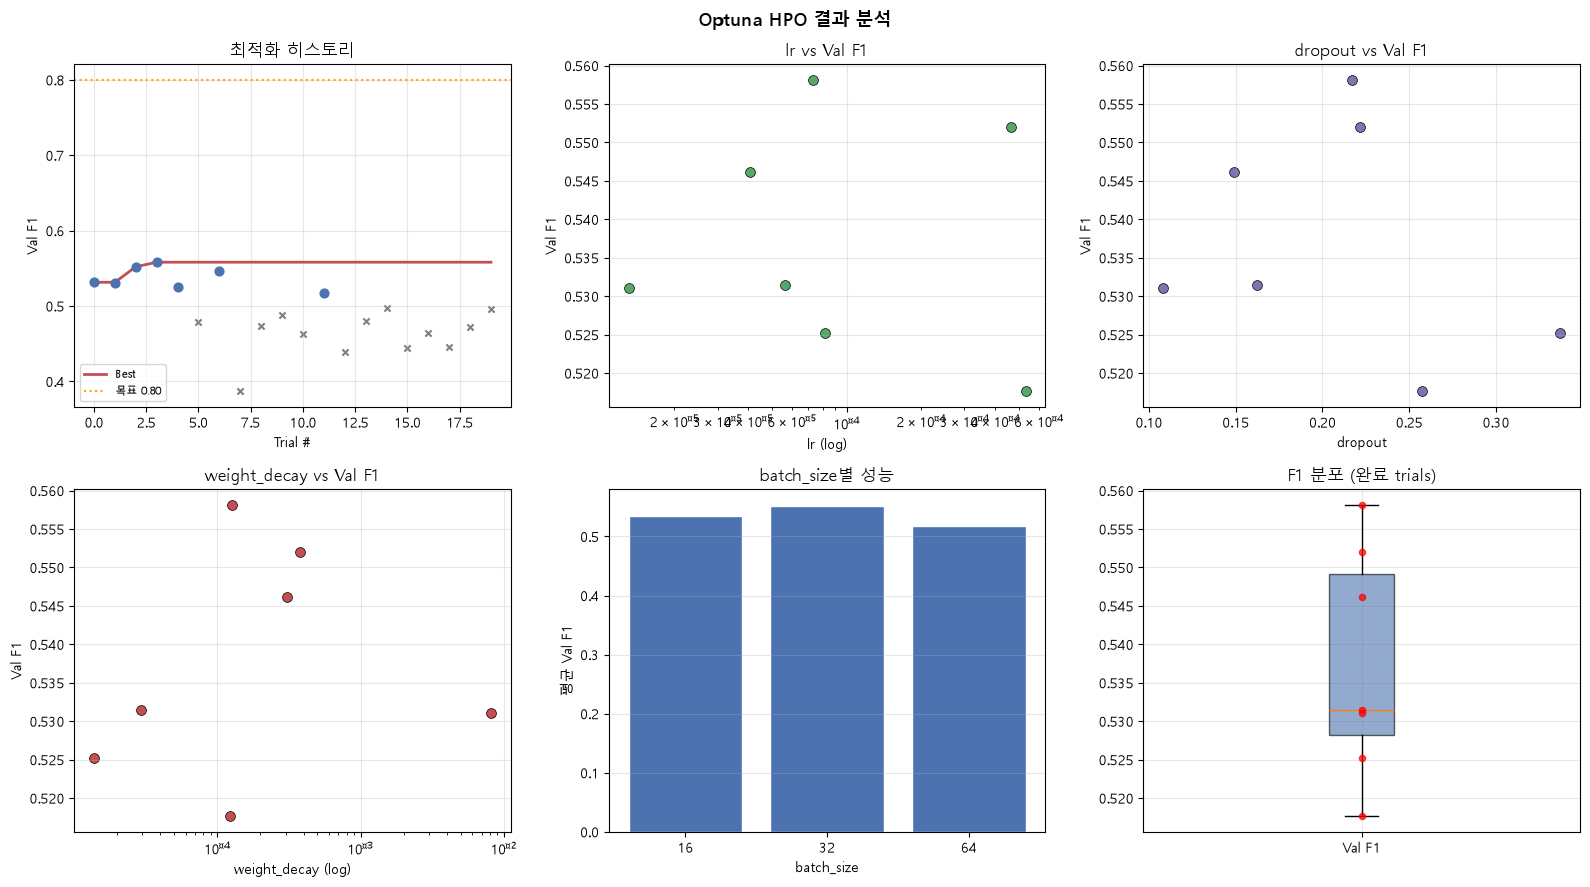

저장: analysis/hpo_analysis.png


In [12]:
rows = []
for t in study.trials:
    if t.state in (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED):
        row = {'trial': t.number,
               'val_f1': t.value if t.value is not None else 0.0,
               'state': t.state.name}
        row.update(t.params)
        rows.append(row)
df_trials = pd.DataFrame(rows).sort_values('val_f1', ascending=False)
print(df_trials.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Optuna HPO 결과 분석', fontsize=13, fontweight='bold')

# 최적화 히스토리
ax = axes[0, 0]
best_so_far = []
cur_best = 0.0
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None:
        ax.scatter(t.number, t.value, color='#4C72B0', s=40, zorder=3)
        cur_best = max(cur_best, t.value)
    else:
        ax.scatter(t.number, t.value if t.value else 0, color='gray', s=20, marker='x')
    best_so_far.append(cur_best)
ax.plot(range(len(best_so_far)), best_so_far, color='#C44E52', linewidth=2, label='Best')
ax.axhline(0.80, linestyle=':', color='orange', linewidth=1.5, label='목표 0.80')
ax.set_title('최적화 히스토리'); ax.set_xlabel('Trial #'); ax.set_ylabel('Val F1')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

df_c = df_trials[df_trials['state'] == 'COMPLETE']

# lr vs Val F1
ax = axes[0, 1]
if 'lr' in df_c.columns:
    ax.scatter(df_c['lr'], df_c['val_f1'], c='#55A868', s=50, edgecolors='k', linewidths=0.5)
    ax.set_xscale('log')
ax.set_xlabel('lr (log)'); ax.set_ylabel('Val F1'); ax.set_title('lr vs Val F1'); ax.grid(alpha=0.3)

# dropout vs Val F1
ax = axes[0, 2]
if 'dropout' in df_c.columns:
    ax.scatter(df_c['dropout'], df_c['val_f1'], c='#8172B2', s=50, edgecolors='k', linewidths=0.5)
ax.set_xlabel('dropout'); ax.set_ylabel('Val F1'); ax.set_title('dropout vs Val F1'); ax.grid(alpha=0.3)

# weight_decay vs Val F1
ax = axes[1, 0]
if 'weight_decay' in df_c.columns:
    ax.scatter(df_c['weight_decay'], df_c['val_f1'], c='#C44E52', s=50, edgecolors='k', linewidths=0.5)
    ax.set_xscale('log')
ax.set_xlabel('weight_decay (log)'); ax.set_ylabel('Val F1')
ax.set_title('weight_decay vs Val F1'); ax.grid(alpha=0.3)

# batch_size별 평균
ax = axes[1, 1]
if 'batch_size' in df_c.columns and len(df_c) > 0:
    bs_mean = df_c.groupby('batch_size')['val_f1'].mean().sort_index()
    ax.bar([str(x) for x in bs_mean.index], bs_mean.values, color='#4C72B0', edgecolor='white')
    ax.set_xlabel('batch_size'); ax.set_ylabel('평균 Val F1')
ax.set_title('batch_size별 성능'); ax.grid(axis='y', alpha=0.3)

# F1 분포
ax = axes[1, 2]
f1_vals = df_c['val_f1'].tolist()
if f1_vals:
    ax.boxplot([f1_vals], tick_labels=['Val F1'], patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    ax.scatter([1]*len(f1_vals), f1_vals, color='red', s=20, zorder=5, alpha=0.7)
ax.set_title('F1 분포 (완료 trials)'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'hpo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: analysis/hpo_analysis.png')

## 8. 최적 파라미터로 최종 모델 재학습

In [13]:
best_p = study.best_params
print('=== 최적 하이퍼파라미터 ===')
for k, v in best_p.items():
    print(f'  {k:<16}: {v}')

best_bs      = best_p['batch_size']
best_t_loader = DataLoader(train_dataset, batch_size=best_bs,
                           sampler=weighted_sampler, num_workers=0)
best_v_loader = DataLoader(val_dataset, batch_size=best_bs, shuffle=False, num_workers=0)

best_model     = WaferCNN(num_classes=NUM_CLASSES, dropout=best_p['dropout']).to(DEVICE)
best_optimizer = optim.Adam(best_model.parameters(),
                            lr=best_p['lr'], weight_decay=best_p['weight_decay'])
best_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    best_optimizer, T_max=FULL_EPOCHS, eta_min=1e-7
)

best_val_f1   = 0.0
patience_cnt  = 0
best_ckpt_path = CHECKPOINT_DIR / 'WaferCNN_best_hpo.pth'
history = {'train_loss': [], 'val_f1': []}

print(f'\n전체 재학습 — {FULL_EPOCHS} epochs (patience={PATIENCE})')
print('  Ep | Tr Loss | Vl F1  | Best')

with mlflow.start_run(run_name='Step6_BestModel_Retrain',
                      tags={'type': 'best_retrain', 'step': '6'}) as run:
    mlflow.log_params({
        'model':        'WaferCNN',
        'lr':           best_p['lr'],
        'batch_size':   best_p['batch_size'],
        'dropout':      best_p['dropout'],
        'weight_decay': best_p['weight_decay'],
        'epochs':       FULL_EPOCHS,
        'patience':     PATIENCE,
        'scheduler':    'CosineAnnealingLR',
    })
    best_run_id = run.info.run_id

    for ep in range(1, FULL_EPOCHS + 1):
        tr_loss, _ = train_one_epoch(best_model, best_t_loader, criterion, best_optimizer, DEVICE)
        _, _, val_f1 = eval_epoch(best_model, best_v_loader, criterion, DEVICE)
        best_scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_f1'].append(val_f1)
        mlflow.log_metrics({'train_loss': tr_loss, 'val_f1_macro': val_f1}, step=ep)

        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1 = val_f1
            patience_cnt = 0
            torch.save({'epoch': ep, 'model_state': best_model.state_dict(),
                        'val_f1': val_f1, 'best_params': best_p}, best_ckpt_path)
        else:
            patience_cnt += 1

        print(f'  {ep:>2} | {tr_loss:.4f}  | {val_f1:.4f} | {"★" if is_best else ""}')
        if patience_cnt >= PATIENCE:
            print(f'  EarlyStopping (ep={ep})')
            break

    # 최적 가중치로 테스트 평가
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=True)
    best_model.load_state_dict(ckpt['model_state'])
    _, test_acc, test_f1 = eval_epoch(best_model, test_loader, criterion, DEVICE)
    mlflow.log_metrics({'test_accuracy': test_acc, 'test_f1_macro': test_f1})

    # 모델 아티팩트 로깅
    try:
        sample_input = torch.zeros(1, 1, 64, 64)
        mlflow.pytorch.log_model(
            best_model.cpu(),
            artifact_path='wafer_cnn_model',
            input_example=sample_input.numpy(),
        )
        best_model.to(DEVICE)
    except Exception as e:
        print(f'모델 아티팩트 로깅 실패 (무시): {e}')
        best_model.to(DEVICE)

print(f'\n=== 재학습 완료 ===')
print(f'  Best Val F1 : {best_val_f1:.4f}')
print(f'  Test F1     : {test_f1:.4f}')
print(f'  Test Acc    : {test_acc*100:.2f}%')

=== 최적 하이퍼파라미터 ===
  lr              : 7.309539835912905e-05
  batch_size      : 32
  dropout         : 0.21685785941408728
  weight_decay    : 0.00012562773503807024

전체 재학습 — 30 epochs (patience=7)
  Ep | Tr Loss | Vl F1  | Best
   1 | 0.3264  | 0.4315 | ★
   2 | 0.1680  | 0.4304 | 
   3 | 0.1230  | 0.4695 | ★
   4 | 0.0974  | 0.4750 | ★
   5 | 0.0873  | 0.4956 | ★
   6 | 0.0768  | 0.4934 | 
   7 | 0.0695  | 0.5123 | ★
   8 | 0.0621  | 0.4697 | 
   9 | 0.0610  | 0.4861 | 
  10 | 0.0542  | 0.5024 | 
  11 | 0.0519  | 0.5251 | ★
  12 | 0.0472  | 0.5501 | ★
  13 | 0.0450  | 0.5409 | 
  14 | 0.0424  | 0.5224 | 
  15 | 0.0401  | 0.5648 | ★
  16 | 0.0373  | 0.5423 | 
  17 | 0.0357  | 0.6099 | ★
  18 | 0.0339  | 0.5564 | 
  19 | 0.0330  | 0.5804 | 
  20 | 0.0311  | 0.5533 | 
  21 | 0.0301  | 0.5896 | 
  22 | 0.0287  | 0.5778 | 
  23 | 0.0273  | 0.5701 | 
  24 | 0.0264  | 0.5937 | 
  EarlyStopping (ep=24)


2026/06/21 16:50:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0] Error while creating guard:
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0] Name: ''
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0]     Source: shape_env
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0]     Create Function: SHAPE_ENV
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0]     Guard Types: None
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0]     Code List: None
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0]     Object Weakref: None
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0]     Guarded Class Weakref: None
E0621 16:50:04.993000 30980 Lib\site-packages\torch\_guards.py:295] [0/0] Traceback (most recent call last):
E06

모델 아티팩트 로깅 실패 (무시): Constraints violated (dynamic_dim)! For more information, run with TORCH_LOGS="+dynamic".
  - Not all values of dynamic_dim = L['x'].size()[0] in the specified range are valid because dynamic_dim was inferred to be a constant (1).

Suggested fixes:
  dynamic_dim = 1

=== 재학습 완료 ===
  Best Val F1 : 0.6099
  Test F1     : 0.5987
  Test Acc    : 43.21%


## 9. MLFlow 모델 레지스트리 등록

In [14]:
client = MlflowClient(tracking_uri=TRACKING_URI)

model_uri  = f'runs:/{best_run_id}/wafer_cnn_model'
try:
    reg_result = mlflow.register_model(model_uri=model_uri, name=MODEL_REGISTRY)
    version    = reg_result.version
    print(f'모델 등록 완료: {MODEL_REGISTRY} v{version}')

    client.update_registered_model(
        name=MODEL_REGISTRY,
        description='WaferCNN — WM-811K 웨이퍼 불량 검출. Optuna HPO 최적 파라미터.'
    )
    client.update_model_version(
        name=MODEL_REGISTRY, version=version,
        description=(
            f'lr={best_p["lr"]:.2e}, batch={best_p["batch_size"]}, '
            f'dropout={best_p["dropout"]:.3f}, wd={best_p["weight_decay"]:.2e} | '
            f'Test F1={test_f1:.4f}'
        )
    )

    try:
        client.set_registered_model_alias(
            name=MODEL_REGISTRY, alias='champion', version=version
        )
        print(f'alias 설정: champion → v{version}')
    except Exception as e:
        print(f'alias 설정 실패 (MLFlow UI에서 수동 설정): {e}')

    for mv in client.search_model_versions(f"name='{MODEL_REGISTRY}'"):
        print(f'  v{mv.version} | run={mv.run_id[:8]}... | {(mv.description or "")[:60]}')

except Exception as e:
    print(f'모델 레지스트리 등록 실패: {e}')
    print('체크포인트는 checkpoints/WaferCNN_best_hpo.pth 에 저장됨')
    version = 'N/A'

Successfully registered model 'WaferDefectCNN'.
2026/06/21 16:50:05 WARNING mlflow.tracking._model_registry.fluent: Run with id ec896dbbf4d046b2851cd90fa3158fe9 has no artifacts at artifact path 'wafer_cnn_model', registering model based on models:/m-a342a672be434bdf937ad6801bae97b8 instead


모델 등록 완료: WaferDefectCNN v1
alias 설정: champion → v1
  v1 | run=ec896dbb... | lr=7.31e-05, batch=32, dropout=0.217, wd=1.26e-04 | Test F1=


Created version '1' of model 'WaferDefectCNN'.


## 10. 산출물 저장

In [15]:
hpo_summary = {
    'study_name': 'wafer-cnn-hpo',
    'n_trials':   N_TRIALS,
    'completed':  len(completed),
    'pruned':     len(pruned),
    'best_trial': study.best_trial.number,
    'best_val_f1':round(float(study.best_value), 4),
    'best_params': {k: (round(float(v), 6) if isinstance(v, float) else v)
                    for k, v in study.best_params.items()},
    'retrain_result': {
        'test_accuracy': round(float(test_acc), 4),
        'test_f1_macro': round(float(test_f1),  4),
        'best_val_f1':   round(float(best_val_f1), 4),
    },
    'mlflow': {
        'tracking_uri':     TRACKING_URI,
        'experiment_name':  EXPERIMENT_NAME,
        'best_run_id':      best_run_id,
        'registry_name':    MODEL_REGISTRY,
        'registry_version': str(version),
    },
}

json_path = ANALYSIS_DIR / 'hpo_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(hpo_summary, f, ensure_ascii=False, indent=2)
print(f'결과: {json_path}')

csv_path = ANALYSIS_DIR / 'hpo_trials.csv'
df_trials.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'Trial: {csv_path}')

print()
print('=== Phase 1 Step 6 완료 ===')
print(f'  lr          : {best_p["lr"]:.2e}')
print(f'  batch_size  : {best_p["batch_size"]}')
print(f'  dropout     : {best_p["dropout"]:.3f}')
print(f'  weight_decay: {best_p["weight_decay"]:.2e}')
print(f'  Test F1     : {test_f1:.4f}')
print()
print(f'MLFlow UI: mlflow ui --backend-store-uri "{TRACKING_URI}"')
print('다음 단계: 07_airflow_pipeline')

결과: analysis\hpo_results.json
Trial: analysis\hpo_trials.csv

=== Phase 1 Step 6 완료 ===
  lr          : 7.31e-05
  batch_size  : 32
  dropout     : 0.217
  weight_decay: 1.26e-04
  Test F1     : 0.5987

MLFlow UI: mlflow ui --backend-store-uri "sqlite:///mlruns/mlflow.db"
다음 단계: 07_airflow_pipeline
